In [ ]:
!pip install pgmpy pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 48.6 MB/s eta 0:00:00


2. Define the Simplified Bayesian Network Structure

In [ ]:
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import ParameterEstimator
from pgmpy.sampling import BayesianModelSampling
from pgmpy.inference import VariableElimination

# Define the Nodes and Edges (Attack Dependencies)
attack_model = DiscreteBayesianNetwork([
    ('SE', 'PH'),
    ('PH', 'MI'),
    ('MI', 'DoS'),
    ('MI', 'MitM'),
])

print("--- Bayesian Network Structure Defined ---")
print("Nodes:", attack_model.nodes)
print("Edges:", attack_model.edges)

--- Bayesian Network Structure Defined ---
Nodes: ['SE', 'PH', 'MI', 'DoS', 'MitM']
Edges: [('SE', 'PH'), ('PH', 'MI'), ('MI', 'DoS'), ('MI', 'MitM')]


3. Simulate Attack Data

In [ ]:
from pgmpy.factors.discrete import TabularCPD

# Define initial CPTs for simulation (P(SE=1)=0.2)
cpd_se = TabularCPD(variable='SE', variable_card=2, values=[[0.8], [0.2]])

# Conditional probability for PH, given SE
cpd_ph = TabularCPD(variable='PH', variable_card=2,
                    values=[[0.8, 0.2],
                            [0.2, 0.8]],
                    evidence=['SE'], evidence_card=[2])

# Define CPD for MI, given PH
cpd_mi = TabularCPD(variable='MI', variable_card=2,
                    values=[[0.9, 0.3],
                            [0.1, 0.7]],
                    evidence=['PH'], evidence_card=[2])

# Define CPD for DoS, given MI
cpd_dos = TabularCPD(variable='DoS', variable_card=2,
                     values=[[0.95, 0.1],
                             [0.05, 0.9]],
                     evidence=['MI'], evidence_card=[2])

# Define CPD for MitM, given MI
cpd_mitm = TabularCPD(variable='MitM', variable_card=2,
                      values=[[0.98, 0.2],
                              [0.02, 0.8]],
                      evidence=['MI'], evidence_card=[2])

# Adding the CPDs to the model *before* creating the sampler
attack_model.add_cpds(cpd_se, cpd_ph, cpd_mi, cpd_dos, cpd_mitm)

# Sample a large dataset (10,000 samples)
sampler = BayesianModelSampling(attack_model)
simulated_data = sampler.forward_sample(size=10000)

print("\n--- Simulated Data Head (10,000 attack events) ---")
print(simulated_data.head())

  0%|          | 0/5 [00:00<?, ?it/s]


--- Simulated Data Head (10,000 attack events) ---
   SE  PH  MI  DoS  MitM
0   0   0   0    1     0
1   0   1   1    1     0
2   1   1   0    0     0
3   0   0   0    1     0
4   0   0   0    0     0


4. Parameter Learning (Estimating CPTs)

In [ ]:
# Initialize the ParameterEstimator
estimator = ParameterEstimator(attack_model, simulated_data)

# Fit the model using Maximum Likelihood Estimation (MLM)
attack_model.fit(simulated_data)

print("\n--- Learned Conditional Probability Table (CPT) for MitM ---")
print(attack_model.get_cpds('MitM'))


--- Learned Conditional Probability Table (CPT) for MitM ---
+---------+----------------------+--------------------+
| MI      | MI(0)                | MI(1)              |
+---------+----------------------+--------------------+
| MitM(0) | 0.9766197183098592   | 0.1906896551724138 |
+---------+----------------------+--------------------+
| MitM(1) | 0.023380281690140847 | 0.8093103448275862 |
+---------+----------------------+--------------------+


5. Risk Inference and Calculation

In [ ]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the inference engine
inference = VariableElimination(attack_model)

# Calculate the probability of the target attacks occurring (P)
p_dos_success = inference.query(variables=['DoS'], evidence={})
p_mitm_success = inference.query(variables=['MitM'], evidence={})

# Extract the P(Attack = 1) value
p_dos = p_dos_success.values[1]
p_mitm = p_mitm_success.values[1]

# Define Impact Values (I) (Hypothetical)
impact_dos = 40
impact_mitm = 80

# Calculate Final Risk (R = P * I)
risk_dos = p_dos * impact_dos
risk_mitm = p_mitm * impact_mitm

print("\n--- Final Risk Assessment ---")
print(f"Calculated Risk (DoS): {risk_dos:.2f}")
print(f"Calculated Risk (MitM): {risk_mitm:.2f}")

# Conclusion based on risk comparison
if risk_dos > risk_mitm:
    print("\nConclusion: DoS Attack presents the higher risk.")
else:
    print("\nConclusion: MitM Attack presents the higher risk.")


--- Final Risk Assessment ---
Calculated Risk (DoS): 11.91
Calculated Risk (MitM): 20.10

Conclusion: MitM Attack presents the higher risk.


Visualization of Results

/tmp/ipython-input-3302128038.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Attack Type', y='Risk Value', data=risk_df, palette='viridis')


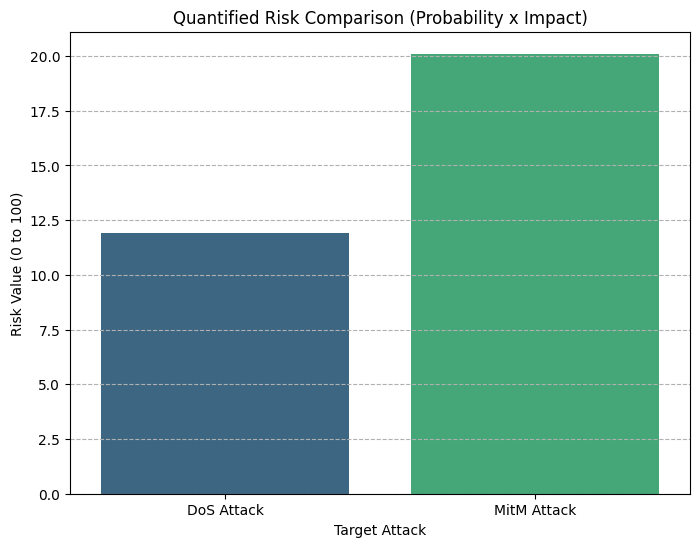

In [ ]:

risks = {
    'DoS Attack': risk_dos,
    'MitM Attack': risk_mitm
}

risk_df = pd.DataFrame(risks.items(), columns=['Attack Type', 'Risk Value'])


plt.figure(figsize=(8, 6))
sns.barplot(x='Attack Type', y='Risk Value', data=risk_df, palette='viridis')
plt.title('Quantified Risk Comparison (Probability x Impact)')
plt.ylabel('Risk Value (0 to 100)')
plt.xlabel('Target Attack')
plt.grid(axis='y', linestyle='--')
plt.show()